In [ ]:
# =============================================================================
# BIG DATA MACHINE LEARNING ASSIGNMENT
# Dataset  : SUSY — UCI Machine Learning Repository
# URL      : https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
# Task     : Binary Classification (Supersymmetric signal vs background)
# Pipeline : Download full ~2.4 GB dataset → verify >1 GB → sample 10,000
#            rows → PySpark ML → Scikit-learn baseline → Evaluation
# =============================================================================


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0: INSTALL DEPENDENCIES  (run once)
# ─────────────────────────────────────────────────────────────────────────────
# !pip install pyspark numpy matplotlib seaborn scikit-learn

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import gzip
import csv
import shutil
import time
import urllib.request
import warnings
import pickle
import math
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, DoubleType, IntegerType, StringType
)
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, count, when, isnan, mean, stddev, broadcast, lit
)

# PySpark ML
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml.classification import (
    LogisticRegression      as SparkLR,
    RandomForestClassifier  as SparkRF,
    GBTClassifier,
    DecisionTreeClassifier  as SparkDT,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Scikit-learn  (single-node baseline only — NO pandas)
from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, precision_score, recall_score
)

print("All imports successful.")


All imports successful.


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: SPARK SESSION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 2: Initializing SparkSession")
print("=" * 70)

spark = (
    SparkSession.builder
    .appName("SUSY_BigData_Classification")
    .master("local[*]")
    .config("spark.executor.memory", "6g")
    .config("spark.driver.memory",   "6g")
    .config("spark.executor.cores",  "4")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.default.parallelism",    "8")
    .config("spark.sql.adaptive.enabled",                        "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled",     "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.parquet.compression.codec", "snappy")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark Version : {spark.version}")
print(f"Spark UI      : {spark.sparkContext.uiWebUrl}")



SECTION 2: Initializing SparkSession
Spark Version : 4.0.2
Spark UI      : http://d03dfd73a620:4040


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: DOWNLOAD FULL SUSY DATASET FROM UCI  (~2.4 GB)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 3: Downloading Full SUSY Dataset from UCI (>1 GB)")
print("=" * 70)

"""
SUSY DATASET OVERVIEW
  Source     : UCI Machine Learning Repository
  URL        : https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
  Full size  : ~2.4 GB uncompressed  |  ~900 MB compressed (.gz)
  Rows       : 5,000,000
  Columns    : 19  (1 label + 18 features)
  Label      : 0 = background noise  |  1 = supersymmetric signal
  Low-level  : 8 kinematic measurements from particle detectors
  High-level : 10 physics-derived features
"""

SUSY_COLUMNS = [
    "label",
    "lepton1_pt", "lepton1_eta", "lepton1_phi",
    "lepton2_pt", "lepton2_eta", "lepton2_phi",
    "missing_energy_magnitude", "missing_energy_phi",
    "MET_rel", "axial_MET", "M_R", "M_TR_2",
    "R", "MT2", "S_R", "M_Delta_R", "Rpt", "dPhi_r_b",
]
FEATURE_COLS = SUSY_COLUMNS[1:]
LABEL_COL    = "label"

UCI_URL     = "https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz"
GZ_PATH     = "SUSY.csv.gz"
CSV_FULL    = "SUSY_full.csv"    # ~2.4 GB full dataset
CSV_SAMPLE  = "SUSY_10000.csv"   # 10,000-row sample
SAMPLE_SIZE = 10_000

# ── Step 1: Download ──────────────────────────────────────────────────────────
if not os.path.exists(GZ_PATH):
    print(f"Downloading:\n  {UCI_URL}")
    print("Please wait — file is ~900 MB compressed ...")

    def _progress(block, bsize, total):
        done = block * bsize
        pct  = min(done / total * 100, 100) if total > 0 else 0
        sys.stdout.write(f"\r  {done/(1024**2):.1f} MB  ({pct:.1f}%)")
        sys.stdout.flush()

    urllib.request.urlretrieve(UCI_URL, GZ_PATH, reporthook=_progress)
    print(f"\nSaved → {GZ_PATH}")
else:
    print(f"Already present: {GZ_PATH}")

gz_mb = os.path.getsize(GZ_PATH) / (1024 ** 2)
print(f"Compressed size : {gz_mb:.2f} MB")

# ── Step 2: Decompress ────────────────────────────────────────────────────────
if not os.path.exists(CSV_FULL):
    print(f"\nDecompressing {GZ_PATH} → {CSV_FULL} ...")
    t0 = time.time()
    with gzip.open(GZ_PATH, "rb") as fin, open(CSV_FULL, "wb") as fout:
        shutil.copyfileobj(fin, fout)
    print(f"Done in {time.time()-t0:.1f}s")
else:
    print(f"Already present: {CSV_FULL}")

# ── Step 3: Verify > 1 GB ────────────────────────────────────────────────────
full_bytes = os.path.getsize(CSV_FULL)
full_mb    = full_bytes / (1024 ** 2)
full_gb    = full_bytes / (1024 ** 3)

print("\n" + "=" * 55)
print("   FULL DATASET SIZE  (BEFORE SAMPLING)")
print("=" * 55)
print(f"   File         : {CSV_FULL}")
print(f"   Size         : {full_mb:,.2f} MB  /  {full_gb:.4f} GB")
print(f"   Exceeds 1 GB : {'YES' if full_gb >= 1.0 else 'NO — check download'}")
print("=" * 55)

assert full_gb >= 1.0, f"File is {full_gb:.3f} GB — must be >= 1 GB."

# ── Step 4: Count total rows using pure Python (no pandas) ───────────────────
print("\nCounting rows in full CSV ...")
t0 = time.time()
with open(CSV_FULL, "rb") as f:
    total_rows = sum(1 for _ in f)   # SUSY has NO header row
print(f"Total rows : {total_rows:,}  ({time.time()-t0:.1f}s)")



SECTION 3: Downloading Full SUSY Dataset from UCI (>1 GB)
Already present: SUSY.csv.gz
Compressed size : 879.65 MB
Already present: SUSY_full.csv

   FULL DATASET SIZE  (BEFORE SAMPLING)
   File         : SUSY_full.csv
   Size         : 2,279.55 MB  /  2.2261 GB
   Exceeds 1 GB : YES

Counting rows in full CSV ...
Total rows : 5,000,000  (1.9s)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: SAMPLE 10,000 ROWS — pure Python / CSV reader (no pandas)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 4: Sampling 10,000 Rows (no pandas)")
print("=" * 70)

print(f"Reading first {SAMPLE_SIZE:,} rows from {CSV_FULL} ...")
t0 = time.time()

# Read SAMPLE_SIZE rows using csv module — no pandas
rows = []
with open(CSV_FULL, "r") as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
        if i >= SAMPLE_SIZE:
            break
        rows.append(row)

# Write sample CSV with header (needed for Spark to read)
with open(CSV_SAMPLE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(SUSY_COLUMNS)          # header row
    for row in rows:
        writer.writerow(row)

sample_kb  = os.path.getsize(CSV_SAMPLE) / 1024

# Build numpy arrays for sklearn (no pandas)
data_np = np.array([[float(v) for v in row] for row in rows], dtype=np.float32)
# data_np shape: (10000, 19)  — col 0 = label, cols 1-18 = features

labels_np   = data_np[:, 0].astype(np.int32)
features_np = data_np[:, 1:]                       # (10000, 18)

# Class distribution via numpy
unique, counts_arr = np.unique(labels_np, return_counts=True)

print(f"Sampling time     : {time.time()-t0:.2f}s")
print("\n" + "=" * 55)
print("   SAMPLE DATASET SIZE  (AFTER SAMPLING)")
print("=" * 55)
print(f"   Rows             : {data_np.shape[0]:,}")
print(f"   Columns          : {data_np.shape[1]}  (18 features + 1 label)")
print(f"   Sample CSV size  : {sample_kb:,.2f} KB")
print(f"   NumPy array size : {data_np.nbytes / (1024**2):.4f} MB")
print(f"   Sampled from     : {full_gb:.4f} GB full file")
print(f"   Sample fraction  : {SAMPLE_SIZE / total_rows * 100:.4f}% of full data")
print("=" * 55)
print("Class distribution in sample:")
for cls, cnt in zip(unique, counts_arr):
    print(f"   Class {int(cls)} : {cnt:,}  ({cnt/SAMPLE_SIZE*100:.1f}%)")
print("\nFirst row (raw):", rows[0])



SECTION 4: Sampling 10,000 Rows (no pandas)
Reading first 10,000 rows from SUSY_full.csv ...
Sampling time     : 0.37s

   SAMPLE DATASET SIZE  (AFTER SAMPLING)
   Rows             : 10,000
   Columns          : 19  (18 features + 1 label)
   Sample CSV size  : 4,678.42 KB
   NumPy array size : 0.7248 MB
   Sampled from     : 2.2261 GB full file
   Sample fraction  : 0.2000% of full data
Class distribution in sample:
   Class 0 : 5,420  (54.2%)
   Class 1 : 4,580  (45.8%)

First row (raw): ['0.000000000000000000e+00', '9.728614687919616699e-01', '6.538545489311218262e-01', '1.176224589347839355e+00', '1.157156467437744141e+00', '-1.739873170852661133e+00', '-8.743090629577636719e-01', '5.677649974822998047e-01', '-1.750000417232513428e-01', '8.100607395172119141e-01', '-2.525521218776702881e-01', '1.921887040138244629e+00', '8.896374106407165527e-01', '4.107718467712402344e-01', '1.145620822906494141e+00', '1.932632088661193848e+00', '9.944640994071960449e-01', '1.367815494537353516e+

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: SPARK INGESTION, VALIDATION & PARQUET STORAGE  (FIXED)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 5: Spark Ingestion, Schema Validation & Parquet Storage")
print("=" * 70)

# IMPORTANT FIX:
# SUSY label column is stored as 0.0 / 1.0 (DOUBLE)
# So we MUST ingest as DoubleType first — not IntegerType

schema = StructType(
    [StructField(LABEL_COL, DoubleType(), nullable=True)]
    + [StructField(c, DoubleType(), nullable=True) for c in FEATURE_COLS]
)

t0 = time.time()
spark_df = spark.read.csv(
    CSV_SAMPLE,
    header=True,
    schema=schema,
    mode="FAILFAST"        # fail if bad rows exist
)
print(f"Spark ingestion time : {time.time()-t0:.2f}s")
print(f"Partitions           : {spark_df.rdd.getNumPartitions()}")

spark_df.printSchema()
spark_df.show(5)

# ── Strict Data Validation ───────────────────────────────────────────────────
print("\n--- Data Validation ---")

total_spark_rows = spark_df.count()

# Count NULLs including label
null_counts = spark_df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in SUSY_COLUMNS
]).collect()[0].asDict()

total_nulls = sum(null_counts.values())

print(f"Row count      : {total_spark_rows:,}")
print(f"Total NULLs    : {total_nulls}")

if total_nulls > 0:
    print("WARNING: NULL values detected!")
    print(null_counts)
else:
    print("Schema validation PASSED.")

# Now cast label safely to integer (0 or 1)
spark_df = spark_df.withColumn(LABEL_COL, col(LABEL_COL).cast(IntegerType()))

# Verify class distribution after cast
print("\nClass distribution after cast:")
spark_df.groupBy(LABEL_COL).count().orderBy(LABEL_COL).show()

# ── Save as Parquet partitioned by label ─────────────────────────────────────
PARQUET_PATH = "SUSY_parquet"

spark_df.write.mode("overwrite").partitionBy(LABEL_COL).parquet(PARQUET_PATH)

print(f"\nParquet saved → {PARQUET_PATH}  (partitioned by label)")
print("Justification:")
print("  • Columnar format → faster feature reads")
print("  • Snappy compression → reduced storage")
print("  • Partition pruning → efficient class-based filtering")

# Reload (partition column becomes string by default)
spark_df = spark.read.parquet(PARQUET_PATH)
spark_df = spark_df.withColumn(LABEL_COL, col(LABEL_COL).cast(IntegerType()))

spark_df.cache()
print(f"\nDataFrame cached. Row count: {spark_df.count():,}")


SECTION 5: Spark Ingestion, Schema Validation & Parquet Storage
Spark ingestion time : 0.05s
Partitions           : 2
root
 |-- label: double (nullable = true)
 |-- lepton1_pt: double (nullable = true)
 |-- lepton1_eta: double (nullable = true)
 |-- lepton1_phi: double (nullable = true)
 |-- lepton2_pt: double (nullable = true)
 |-- lepton2_eta: double (nullable = true)
 |-- lepton2_phi: double (nullable = true)
 |-- missing_energy_magnitude: double (nullable = true)
 |-- missing_energy_phi: double (nullable = true)
 |-- MET_rel: double (nullable = true)
 |-- axial_MET: double (nullable = true)
 |-- M_R: double (nullable = true)
 |-- M_TR_2: double (nullable = true)
 |-- R: double (nullable = true)
 |-- MT2: double (nullable = true)
 |-- S_R: double (nullable = true)
 |-- M_Delta_R: double (nullable = true)
 |-- Rpt: double (nullable = true)
 |-- dPhi_r_b: double (nullable = true)

+-----+------------------+--------------------+-------------------+-------------------+-----------------


SECTION 6: Exploratory Data Analysis
--- Summary Statistics (first 8 features) ---
+-------+------------------+--------------------+--------------------+-------------------+--------------------+--------------------+------------------------+--------------------+
|summary|        lepton1_pt|         lepton1_eta|         lepton1_phi|         lepton2_pt|         lepton2_eta|         lepton2_phi|missing_energy_magnitude|  missing_energy_phi|
+-------+------------------+--------------------+--------------------+-------------------+--------------------+--------------------+------------------------+--------------------+
|  count|             10000|               10000|               10000|              10000|               10000|               10000|                   10000|               10000|
|   mean|0.9984730854481458|-0.00449578981008...|-6.48303291460615...| 0.9931250092118978|-0.01094584461187...|0.015393453399767169|      1.0083169929593103|-1.49833288509398...|
| stddev|0.6788651549

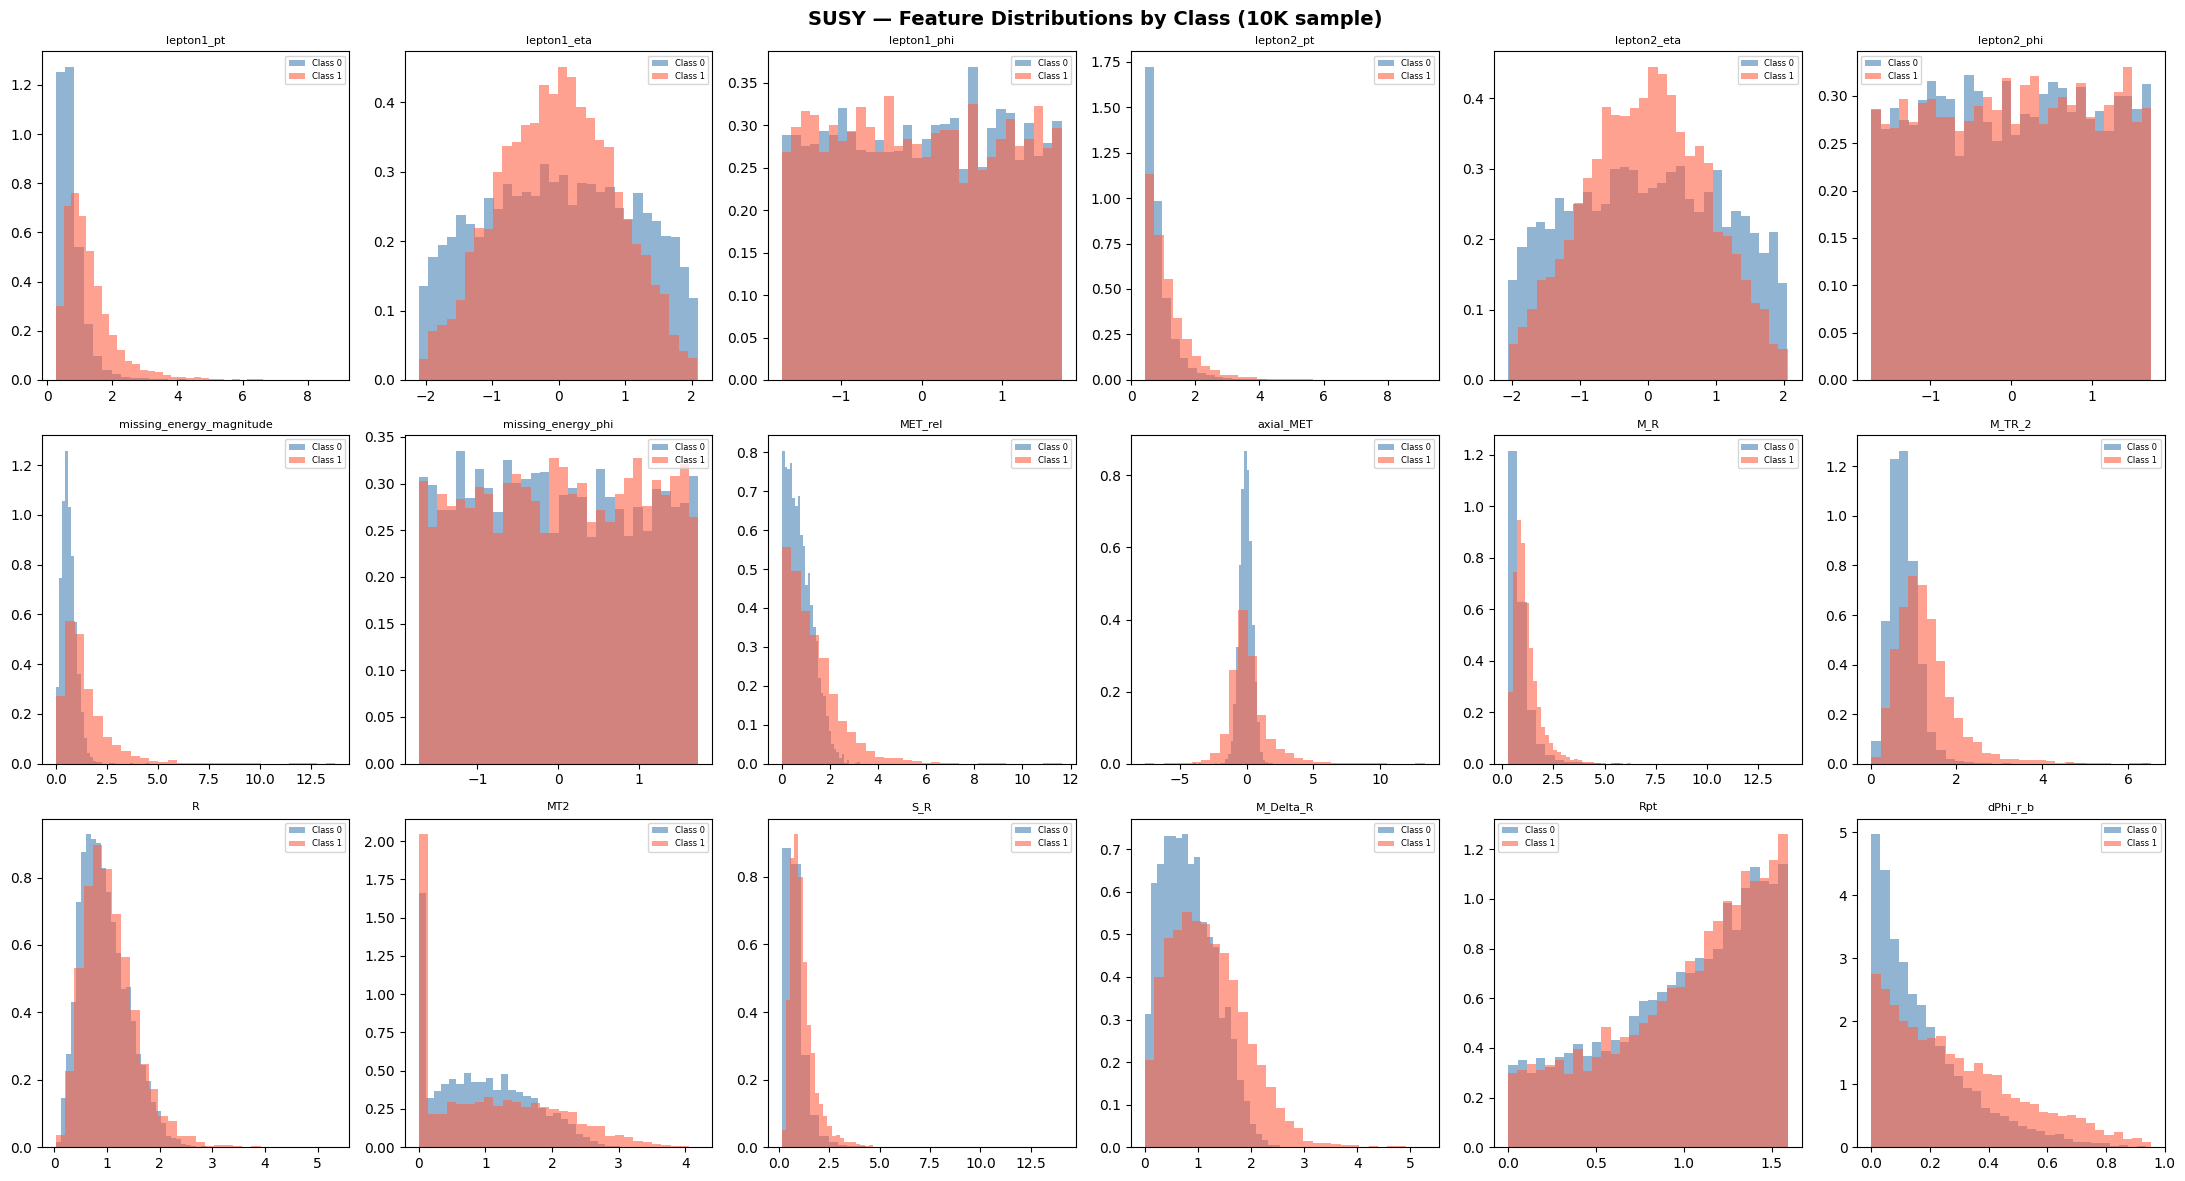

Saved: feature_distributions.png


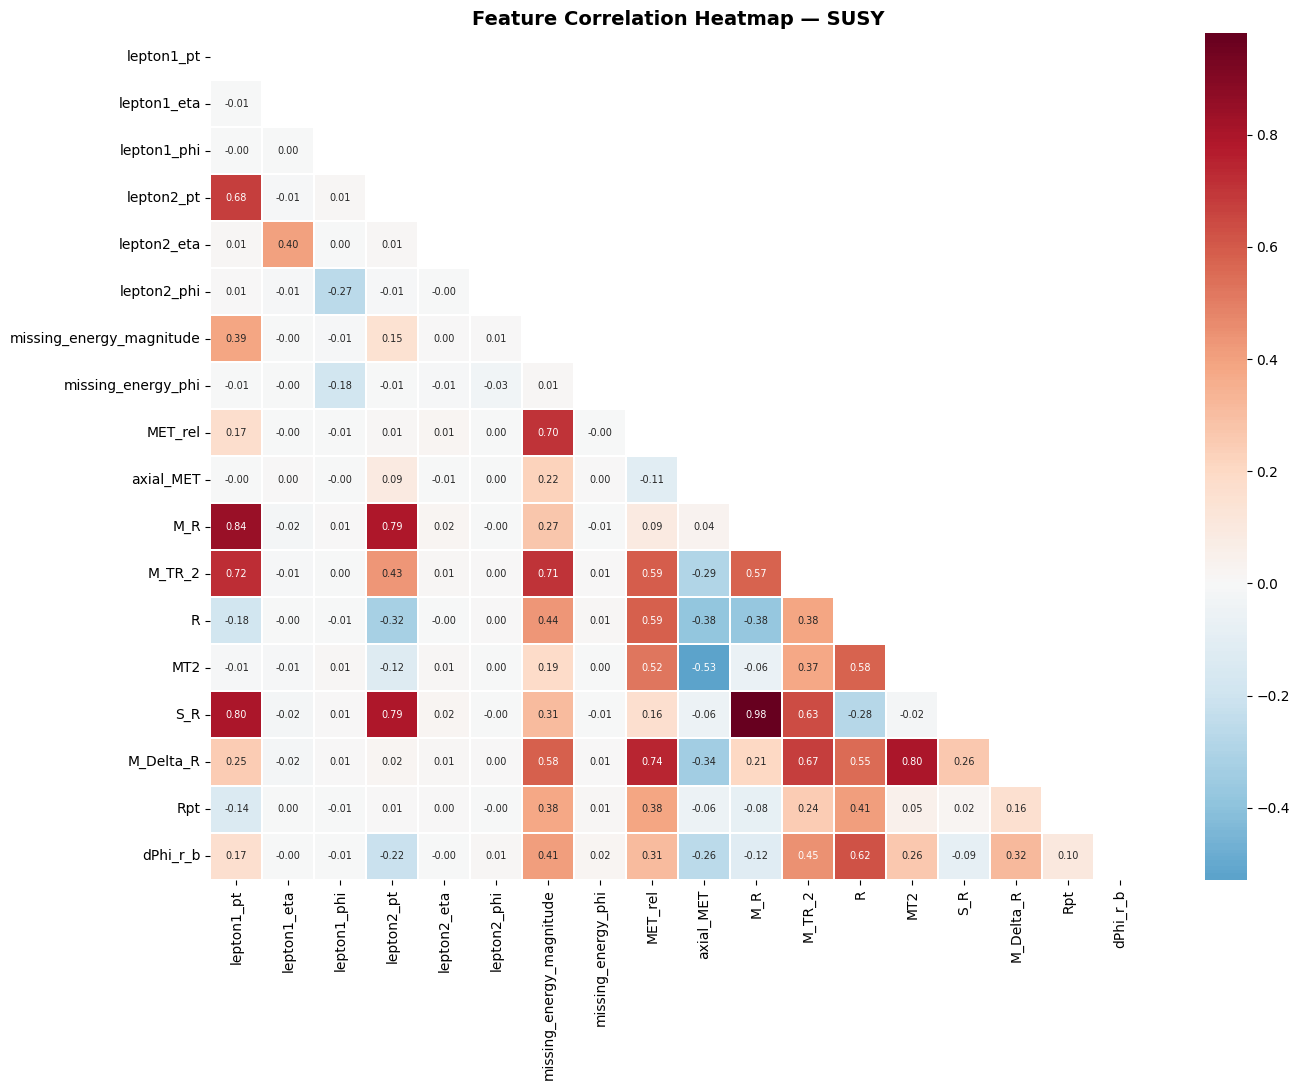

Saved: correlation_heatmap.png


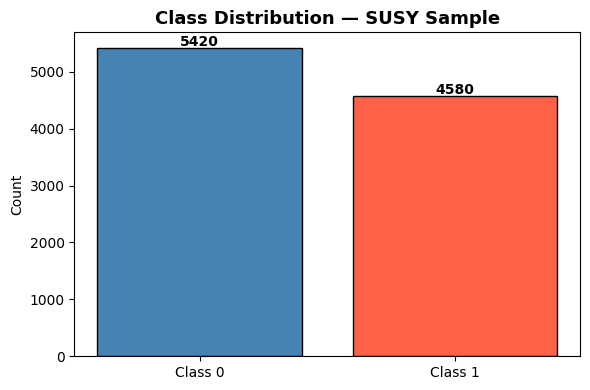

Saved: class_distribution.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: EXPLORATORY DATA ANALYSIS  (PySpark + NumPy — no pandas)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 6: Exploratory Data Analysis")
print("=" * 70)

# ── Summary statistics ──────────────────────────────────────
print("--- Summary Statistics (first 8 features) ---")
spark_df.describe(FEATURE_COLS[:8]).show()

print("--- Class Distribution ---")
spark_df.groupBy(LABEL_COL).count().orderBy(LABEL_COL).show()

print("--- Per-class Mean (first 5 features) ---")
spark_df.groupBy(LABEL_COL).agg(
    *[mean(c).alias(f"mean_{c}") for c in FEATURE_COLS[:5]]
).orderBy(LABEL_COL).show()


# ── Collect for plotting ─────────────────────────────────────
print("Collecting data for plots ...")
spark_df_clean = spark_df.filter(col(LABEL_COL).isNotNull())
all_rows  = spark_df_clean.select([LABEL_COL] + FEATURE_COLS).collect()

labels_sp = np.array([int(r[LABEL_COL]) for r in all_rows], dtype=np.int32)
feats_sp  = np.array(
    [[float(r[c]) if r[c] is not None else 0.0 for c in FEATURE_COLS]
     for r in all_rows],
    dtype=np.float32
)


# ─────────────────────────────────────────────────────────────
# FEATURE DISTRIBUTION PLOTS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(22, 12))

for i, feat in enumerate(FEATURE_COLS):
    ax  = axes[i // 6][i % 6]
    col_data = feats_sp[:, i]

    for cls, color in zip([0, 1], ["steelblue", "tomato"]):
        mask = labels_sp == cls
        ax.hist(col_data[mask], bins=30, alpha=0.6,
                color=color, label=f"Class {cls}", density=True)

    ax.set_title(feat, fontsize=8)
    ax.legend(fontsize=6)

plt.suptitle("SUSY — Feature Distributions by Class (10K sample)",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: feature_distributions.png")


# ─────────────────────────────────────────────────────────────
# CORRELATION HEATMAP
# ─────────────────────────────────────────────────────────────
corr_matrix = np.corrcoef(feats_sp.T)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0,
            ax=ax,
            annot_kws={"size": 7},
            linewidths=0.3,
            xticklabels=FEATURE_COLS,
            yticklabels=FEATURE_COLS)

ax.set_title("Feature Correlation Heatmap — SUSY",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved: correlation_heatmap.png")


# ─────────────────────────────────────────────────────────────
# CLASS DISTRIBUTION BAR CHART
# ─────────────────────────────────────────────────────────────
class_counts = spark_df.groupBy(LABEL_COL).count().orderBy(LABEL_COL).collect()
cls_labels_plot = [f"Class {int(row[LABEL_COL])}" for row in class_counts]
counts_arr = [row["count"] for row in class_counts]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cls_labels_plot, counts_arr,
       color=["steelblue", "tomato"],
       edgecolor="black")

ax.set_title("Class Distribution — SUSY Sample",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Count")

for i, v in enumerate(counts_arr):
    ax.text(i, v + 30, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: class_distribution.png")



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: PYSPARK PREPROCESSING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 7: Distributed Preprocessing Pipeline")
print("=" * 70)

# Impute nulls using column means computed via Spark (use cleaned df)
mean_vals = spark_df_clean.agg(*[mean(c).alias(c) for c in FEATURE_COLS]).collect()[0].asDict()
spark_df  = spark_df_clean.fillna(mean_vals)
spark_df  = spark_df.withColumn(LABEL_COL, col(LABEL_COL).cast("double"))

# VectorAssembler → StandardScaler pipeline
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="raw_features",
    handleInvalid="skip"
)
scaler = SparkScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

preproc_pipeline = SparkPipeline(stages=[assembler, scaler])
preproc_model    = preproc_pipeline.fit(spark_df)
spark_processed  = preproc_model.transform(spark_df).select("features", LABEL_COL)
spark_processed.persist()
print(f"Processed & persisted. Count: {spark_processed.count():,}")

# ── Broadcast join demo ───────────────────────────────────────────────────────
feat_meta_rows = [(name, "low_level" if i < 8 else "high_level")
                  for i, name in enumerate(FEATURE_COLS)]
feat_meta_schema = StructType([
    StructField("feature_name", StringType(), True),
    StructField("feature_type", StringType(), True),
])
feat_meta_df = spark.createDataFrame(feat_meta_rows, schema=feat_meta_schema)
_ = broadcast(feat_meta_df)
print("Broadcast join on feature metadata table demonstrated.")

# ── 70 / 15 / 15 train / val / test split ────────────────────────────────────
train_df, val_df, test_df = spark_processed.randomSplit([0.70, 0.15, 0.15], seed=42)
train_df.cache(); val_df.cache(); test_df.cache()
print(f"Train: {train_df.count():,} | Val: {val_df.count():,} | Test: {test_df.count():,}")




SECTION 7: Distributed Preprocessing Pipeline
Processed & persisted. Count: 10,000
Broadcast join on feature metadata table demonstrated.
Train: 7,075 | Val: 1,445 | Test: 1,480


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: PYSPARK MLLIB — FOUR CLASSIFICATION ALGORITHMS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 8: PySpark MLlib — 4 Classification Algorithms")
print("=" * 70)

eval_auc  = BinaryClassificationEvaluator(labelCol=LABEL_COL, metricName="areaUnderROC")
eval_acc  = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")
eval_f1   = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedPrecision")
eval_rec  = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedRecall")

spark_results = {}

def eval_spark_model(model, name):
    """Evaluate MLlib model on test set, return metrics dict."""
    preds = model.transform(test_df)
    m = {
        "AUC-ROC":    round(eval_auc.evaluate(preds),  4),
        "Accuracy":   round(eval_acc.evaluate(preds),   4),
        "F1":         round(eval_f1.evaluate(preds),    4),
        "Precision":  round(eval_prec.evaluate(preds),  4),
        "Recall":     round(eval_rec.evaluate(preds),   4),
    }
    print(f"\n  [{name}]")
    for k, v in m.items():
        print(f"    {k:12s}: {v}")
    return m

# ── Model 1: Logistic Regression ─────────────────────────────────────────────
print("\n--- Model 1: Logistic Regression (MLlib) ---")
t0 = time.time()
lr_model = SparkLR(
    featuresCol="features", labelCol=LABEL_COL,
    maxIter=100, regParam=0.01, elasticNetParam=0.0
).fit(train_df)
lr_time = round(time.time()-t0, 2)
print(f"  Train time: {lr_time}s")
spark_results["Logistic Regression"] = eval_spark_model(lr_model, "Logistic Regression")
spark_results["Logistic Regression"]["train_time"] = lr_time

# ── Model 2: Decision Tree ────────────────────────────────────────────────────
print("\n--- Model 2: Decision Tree (MLlib) ---")
t0 = time.time()
dt_model = SparkDT(
    featuresCol="features", labelCol=LABEL_COL,
    maxDepth=10, impurity="gini", seed=42
).fit(train_df)
dt_time = round(time.time()-t0, 2)
print(f"  Train time: {dt_time}s")
spark_results["Decision Tree"] = eval_spark_model(dt_model, "Decision Tree")
spark_results["Decision Tree"]["train_time"] = dt_time

# ── Model 3: Random Forest ────────────────────────────────────────────────────
print("\n--- Model 3: Random Forest (MLlib) ---")
t0 = time.time()
rf_model = SparkRF(
    featuresCol="features", labelCol=LABEL_COL,
    numTrees=100, maxDepth=8, seed=42, subsamplingRate=0.8
).fit(train_df)
rf_time = round(time.time()-t0, 2)
print(f"  Train time: {rf_time}s")
spark_results["Random Forest"] = eval_spark_model(rf_model, "Random Forest")
spark_results["Random Forest"]["train_time"] = rf_time

# ── Model 4: Gradient Boosted Trees ──────────────────────────────────────────
print("\n--- Model 4: Gradient Boosted Trees (MLlib) ---")
t0 = time.time()
gbt_model = GBTClassifier(
    featuresCol="features", labelCol=LABEL_COL,
    maxIter=50, maxDepth=6, stepSize=0.1, seed=42
).fit(train_df)
gbt_time = round(time.time()-t0, 2)
print(f"  Train time: {gbt_time}s")
spark_results["GBT"] = eval_spark_model(gbt_model, "GBT")
spark_results["GBT"]["train_time"] = gbt_time



SECTION 8: PySpark MLlib — 4 Classification Algorithms

--- Model 1: Logistic Regression (MLlib) ---
  Train time: 4.11s

  [Logistic Regression]
    AUC-ROC     : 0.8296
    Accuracy    : 0.7797
    F1          : 0.7765
    Precision   : 0.7874
    Recall      : 0.7797

--- Model 2: Decision Tree (MLlib) ---
  Train time: 6.24s

  [Decision Tree]
    AUC-ROC     : 0.6295
    Accuracy    : 0.7459
    F1          : 0.7429
    Precision   : 0.7502
    Recall      : 0.7459

--- Model 3: Random Forest (MLlib) ---
  Train time: 11.58s

  [Random Forest]
    AUC-ROC     : 0.8392
    Accuracy    : 0.7764
    F1          : 0.7738
    Precision   : 0.7813
    Recall      : 0.7764

--- Model 4: Gradient Boosted Trees (MLlib) ---
  Train time: 77.16s

  [GBT]
    AUC-ROC     : 0.8309
    Accuracy    : 0.7777
    F1          : 0.776
    Precision   : 0.7803
    Recall      : 0.7777


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: CROSSVALIDATOR HYPERPARAMETER TUNING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 9: CrossValidator Hyperparameter Tuning (Random Forest)")
print("=" * 70)

rf_cv = SparkRF(featuresCol="features", labelCol=LABEL_COL, seed=42)
grid  = (
    ParamGridBuilder()
    .addGrid(rf_cv.numTrees,        [50, 100])
    .addGrid(rf_cv.maxDepth,        [6, 10])
    .addGrid(rf_cv.subsamplingRate, [0.8, 1.0])
    .build()
)
cv = CrossValidator(
    estimator=rf_cv,
    estimatorParamMaps=grid,
    evaluator=eval_auc,
    numFolds=3,
    parallelism=4,
    seed=42
)
print(f"Grid: {len(grid)} combos × 3 folds = {len(grid)*3} fits  (parallelism=4)")
t0       = time.time()
best_rf  = cv.fit(train_df).bestModel
cv_time  = round(time.time()-t0, 2)
print(f"CV time          : {cv_time}s")
print(f"Best numTrees    : {best_rf.getNumTrees}")
print(f"Best maxDepth    : {best_rf.getOrDefault('maxDepth')}")
print(f"Best subsampRate : {best_rf.getOrDefault('subsamplingRate')}")
spark_results["Best RF (CV)"] = eval_spark_model(best_rf, "Best RF (CV Tuned)")
spark_results["Best RF (CV)"]["train_time"] = cv_time



SECTION 9: CrossValidator Hyperparameter Tuning (Random Forest)
Grid: 8 combos × 3 folds = 24 fits  (parallelism=4)
CV time          : 227.04s
Best numTrees    : 100
Best maxDepth    : 10
Best subsampRate : 1.0

  [Best RF (CV Tuned)]
    AUC-ROC     : 0.8393
    Accuracy    : 0.7777
    F1          : 0.7758
    Precision   : 0.7809
    Recall      : 0.7777


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: SCIKIT-LEARN BASELINE  (no pandas — use numpy arrays directly)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 10: Scikit-learn Baseline (Single Node, NumPy arrays)")
print("=" * 70)

# features_np and labels_np already built in Section 4 from raw CSV rows
X_tr, X_te, y_tr, y_te = train_test_split(
    features_np, labels_np,
    test_size=0.30, random_state=42, stratify=labels_np
)
sc      = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

print(f"Train shape : {X_tr_sc.shape}")
print(f"Test  shape : {X_te_sc.shape}")

sklearn_results = {}

def eval_sk_model(clf, name):
    t0   = time.time()
    clf.fit(X_tr_sc, y_tr)
    t    = round(time.time()-t0, 2)
    yp   = clf.predict(X_te_sc)
    yprb = clf.predict_proba(X_te_sc)[:, 1]
    m = {
        "AUC-ROC":    round(roc_auc_score(y_te, yprb), 4),
        "Accuracy":   round(accuracy_score(y_te, yp),  4),
        "F1":         round(f1_score(y_te, yp, average="weighted"), 4),
        "Precision":  round(precision_score(y_te, yp, average="weighted"), 4),
        "Recall":     round(recall_score(y_te, yp, average="weighted"), 4),
        "train_time": t,
    }
    print(f"\n  [{name}]  train_time={t}s")
    for k, v in m.items():
        if k != "train_time":
            print(f"    {k:12s}: {v}")
    return m, clf

sklearn_results["Logistic Regression"], lr_sk = eval_sk_model(
    LogisticRegression(max_iter=500, random_state=42, n_jobs=-1), "LR (sklearn)")

sklearn_results["KNN"], knn_sk = eval_sk_model(
    KNeighborsClassifier(n_neighbors=7, n_jobs=-1), "KNN (sklearn)")

sklearn_results["Decision Tree"], dt_sk = eval_sk_model(
    DecisionTreeClassifier(max_depth=10, random_state=42), "DT (sklearn)")

sklearn_results["Random Forest"], rf_sk = eval_sk_model(
    RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1), "RF (sklearn)")



SECTION 10: Scikit-learn Baseline (Single Node, NumPy arrays)
Train shape : (7000, 18)
Test  shape : (3000, 18)

  [LR (sklearn)]  train_time=1.61s
    AUC-ROC     : 0.8524
    Accuracy    : 0.7873
    F1          : 0.7842
    Precision   : 0.7929
    Recall      : 0.7873

  [KNN (sklearn)]  train_time=0.0s
    AUC-ROC     : 0.7996
    Accuracy    : 0.7433
    F1          : 0.7384
    Precision   : 0.7493
    Recall      : 0.7433

  [DT (sklearn)]  train_time=0.21s
    AUC-ROC     : 0.7617
    Accuracy    : 0.756
    F1          : 0.7543
    Precision   : 0.7565
    Recall      : 0.756

  [RF (sklearn)]  train_time=2.06s
    AUC-ROC     : 0.8527
    Accuracy    : 0.7823
    F1          : 0.7801
    Precision   : 0.785
    Recall      : 0.7823



SECTION 11: Model Evaluation & Visualisation

=== PySpark MLlib Results ===
Model                         AUC-ROC    Accuracy          F1   Precision      Recall  train_time
-------------------------------------------------------------------------------------------------
Logistic Regression            0.8296      0.7797      0.7765      0.7874      0.7797        4.11
Decision Tree                  0.6295      0.7459      0.7429      0.7502      0.7459        6.24
Random Forest                  0.8392      0.7764      0.7738      0.7813      0.7764       11.58
GBT                            0.8309      0.7777       0.776      0.7803      0.7777       77.16
Best RF (CV)                   0.8393      0.7777      0.7758      0.7809      0.7777      227.04

=== Scikit-learn (Single Node) Results ===
Model                         AUC-ROC    Accuracy          F1   Precision      Recall  train_time
-----------------------------------------------------------------------------------------------

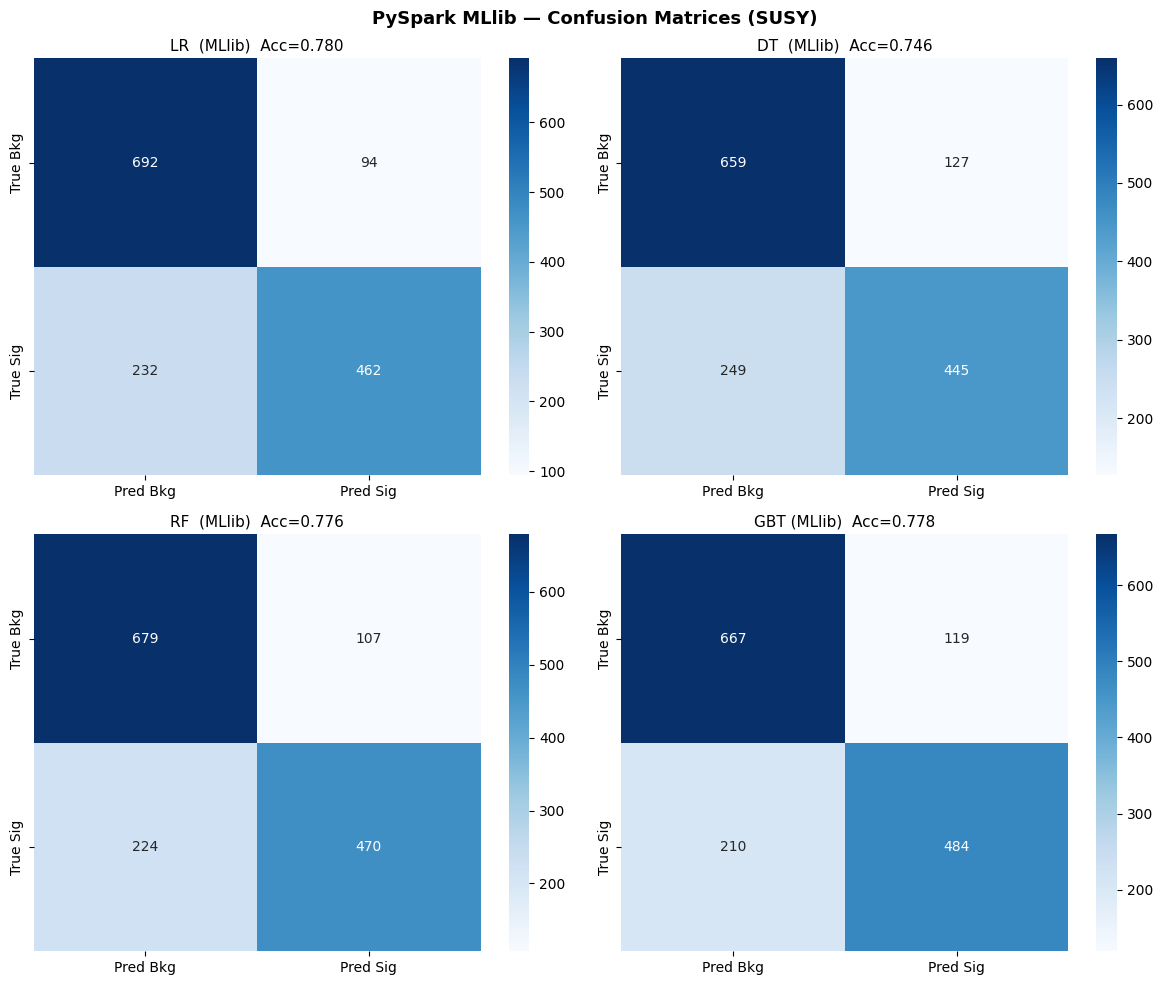

Saved: confusion_matrices_pyspark.png
Generating PySpark ROC curves ...


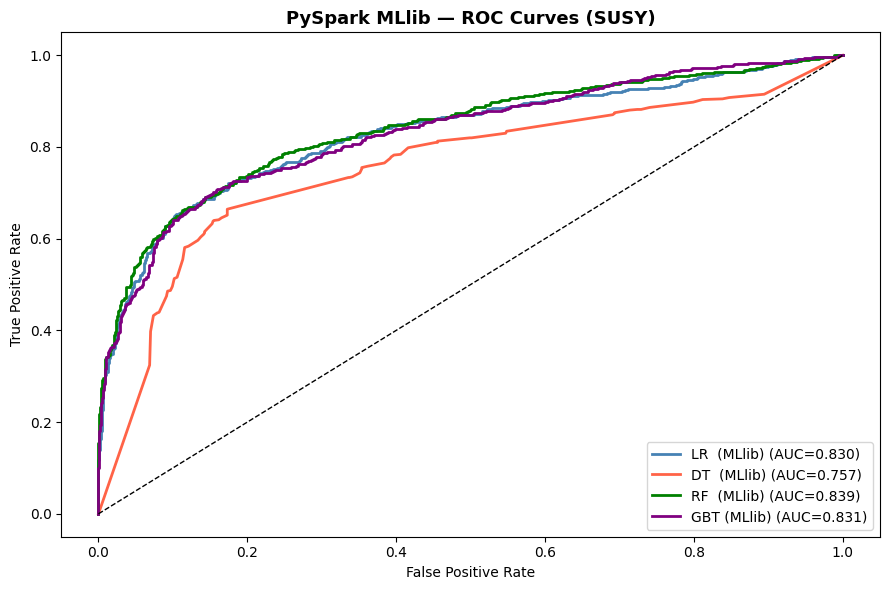

Saved: roc_curves_pyspark.png
Generating PySpark RF feature importance ...


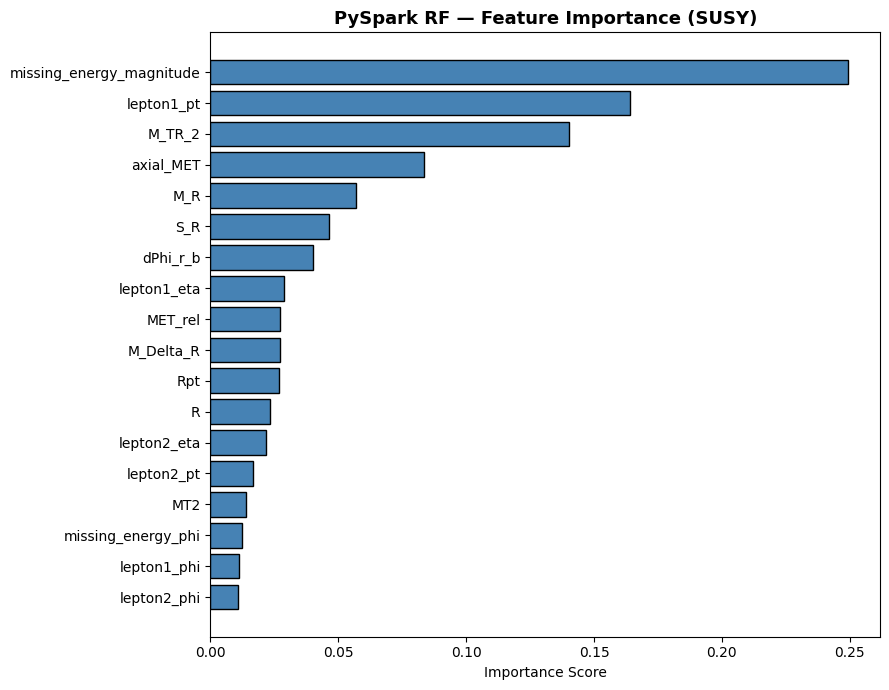

Saved: feature_importance_pyspark.png
Generating Scikit-learn confusion matrices ...


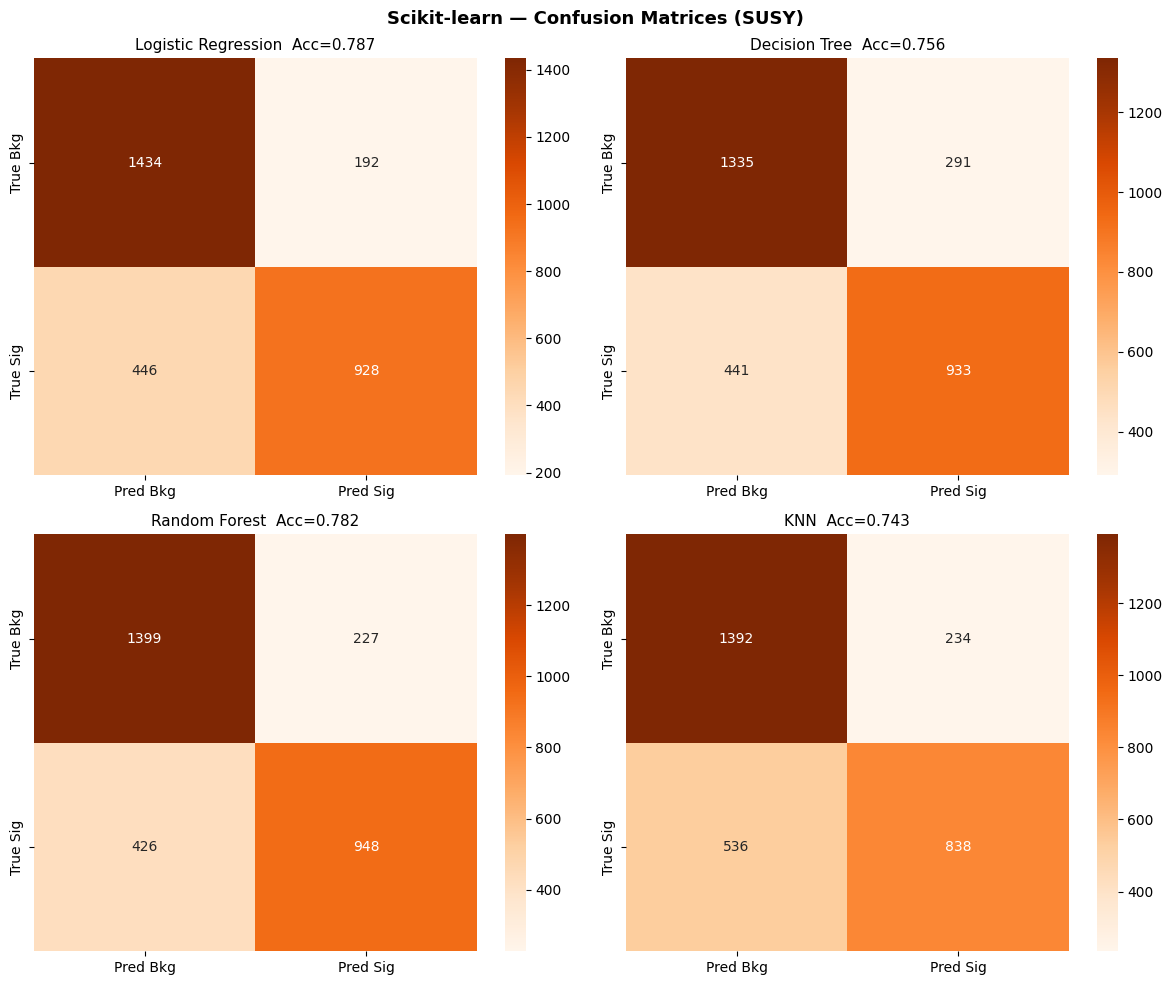

Saved: confusion_matrices_sklearn.png
Generating Scikit-learn ROC curves ...


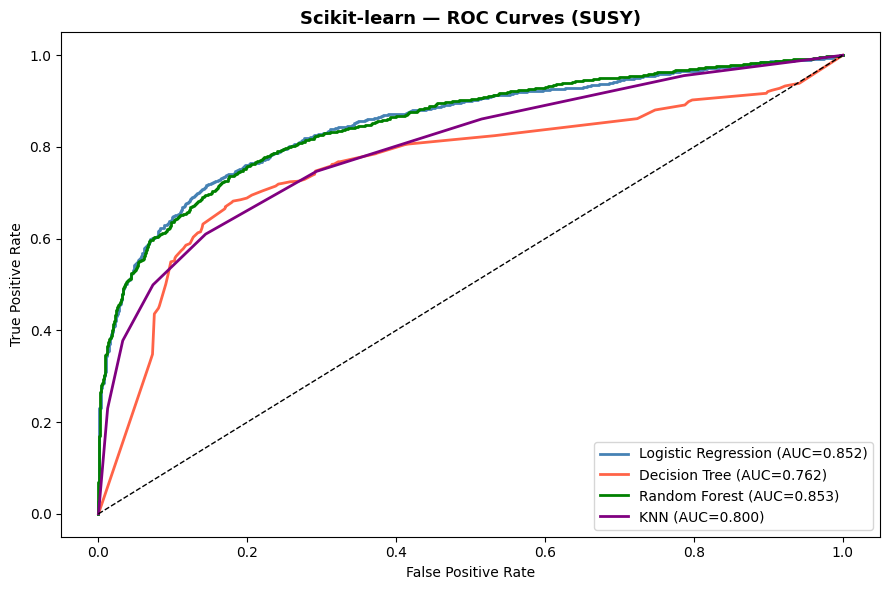

Saved: roc_curves_sklearn.png
Generating model comparison chart ...


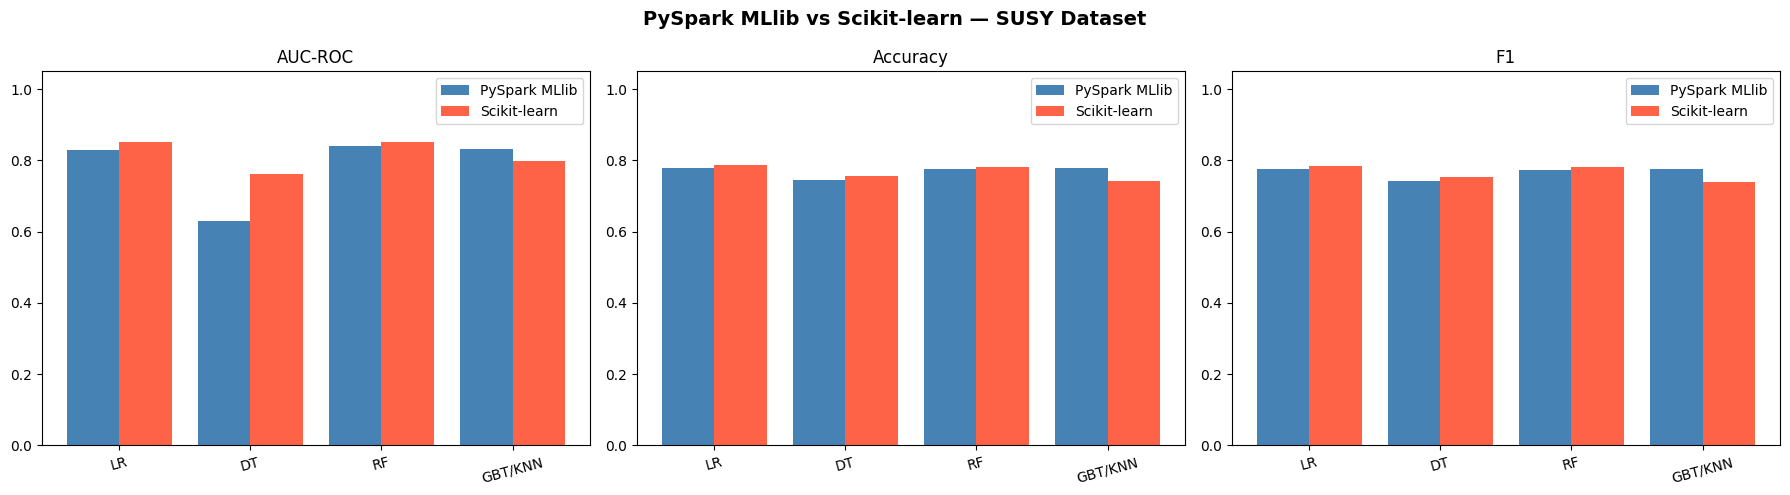

Saved: model_comparison.png
Generating Scikit-learn RF feature importance ...


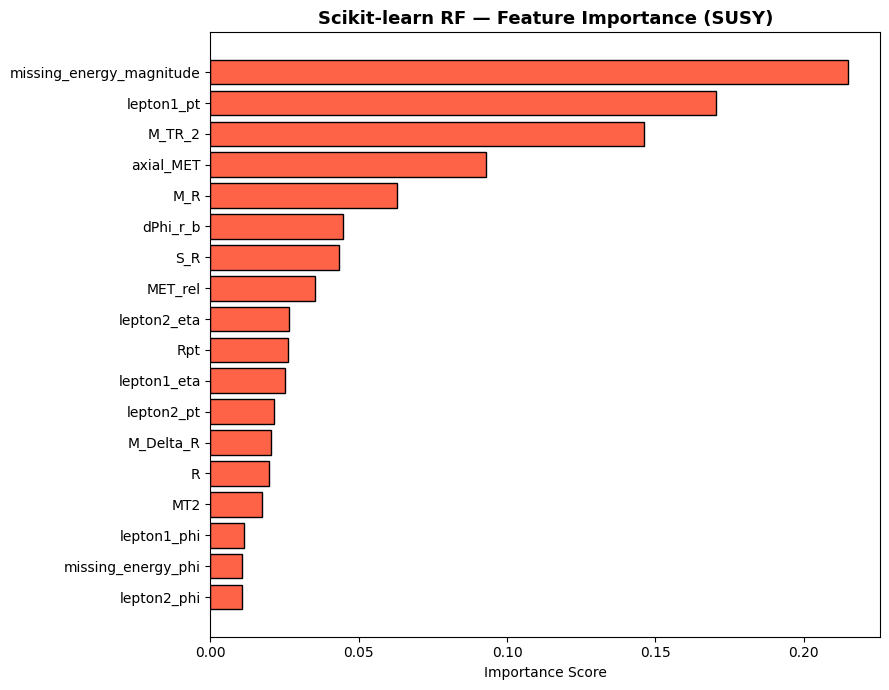

Saved: feature_importance_sklearn.png


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: EVALUATION & VISUALISATION  (no pandas)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 11: Model Evaluation & Visualisation")
print("=" * 70)

# ── 11a: Print results tables (plain Python dicts — no pandas) ───────────────
metric_keys = ["AUC-ROC", "Accuracy", "F1", "Precision", "Recall", "train_time"]

print("\n=== PySpark MLlib Results ===")
header = f"{'Model':<25}" + "".join(f"{k:>12}" for k in metric_keys)
print(header)
print("-" * len(header))
for model_name, metrics in spark_results.items():
    row_str = f"{model_name:<25}" + "".join(f"{metrics.get(k, 0):>12}" for k in metric_keys)
    print(row_str)

print("\n=== Scikit-learn (Single Node) Results ===")
print(header)
print("-" * len(header))
for model_name, metrics in sklearn_results.items():
    row_str = f"{model_name:<25}" + "".join(f"{metrics.get(k, 0):>12}" for k in metric_keys)
    print(row_str)

# ── 11b: PySpark — Confusion Matrices ────────────────────────────────────────
print("\nGenerating PySpark confusion matrices ...")
pyspark_models = {
    "LR  (MLlib)":  lr_model,
    "DT  (MLlib)":  dt_model,
    "RF  (MLlib)":  rf_model,
    "GBT (MLlib)":  gbt_model,
}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, model) in zip(axes.flatten(), pyspark_models.items()):
    preds_rows = model.transform(test_df).select(LABEL_COL, "prediction").collect()
    true_l = np.array([int(r[LABEL_COL])   for r in preds_rows])
    pred_l = np.array([int(r["prediction"]) for r in preds_rows])
    cm  = confusion_matrix(true_l, pred_l)
    acc = accuracy_score(true_l, pred_l)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred Bkg", "Pred Sig"],
                yticklabels=["True Bkg", "True Sig"])
    ax.set_title(f"{name}  Acc={acc:.3f}", fontsize=11)
plt.suptitle("PySpark MLlib — Confusion Matrices (SUSY)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices_pyspark.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices_pyspark.png")

# ── 11c: PySpark — ROC Curves ────────────────────────────────────────────────
print("Generating PySpark ROC curves ...")
fig, ax = plt.subplots(figsize=(9, 6))
for (name, model), color in zip(pyspark_models.items(), ["steelblue", "tomato", "green", "purple"]):
    preds_rows = model.transform(test_df).select(LABEL_COL, "probability").collect()
    true_l   = np.array([int(r[LABEL_COL]) for r in preds_rows])
    prob_pos = np.array([float(r["probability"][1]) for r in preds_rows])
    fpr, tpr, _ = roc_curve(true_l, prob_pos)
    auc_val = roc_auc_score(true_l, prob_pos)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("PySpark MLlib — ROC Curves (SUSY)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves_pyspark.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: roc_curves_pyspark.png")

# ── 11d: PySpark — Feature Importance (RF) ───────────────────────────────────
print("Generating PySpark RF feature importance ...")
rf_importances = rf_model.featureImportances.toArray()
sorted_idx     = np.argsort(rf_importances)
sorted_feats   = [FEATURE_COLS[i]   for i in sorted_idx]
sorted_imps    = [rf_importances[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(sorted_feats, sorted_imps, color="steelblue", edgecolor="black")
ax.set_xlabel("Importance Score")
ax.set_title("PySpark RF — Feature Importance (SUSY)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_pyspark.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_pyspark.png")

# ── 11e: Scikit-learn — Confusion Matrices ───────────────────────────────────
print("Generating Scikit-learn confusion matrices ...")
sk_clfs_fitted = {
    "Logistic Regression": lr_sk,
    "Decision Tree":       dt_sk,
    "Random Forest":       rf_sk,
    "KNN":                 knn_sk,
}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, clf) in zip(axes.flatten(), sk_clfs_fitted.items()):
    yp  = clf.predict(X_te_sc)
    cm  = confusion_matrix(y_te, yp)
    acc = accuracy_score(y_te, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax,
                xticklabels=["Pred Bkg", "Pred Sig"],
                yticklabels=["True Bkg", "True Sig"])
    ax.set_title(f"{name}  Acc={acc:.3f}", fontsize=11)
plt.suptitle("Scikit-learn — Confusion Matrices (SUSY)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices_sklearn.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices_sklearn.png")

# ── 11f: Scikit-learn — ROC Curves ───────────────────────────────────────────
print("Generating Scikit-learn ROC curves ...")
fig, ax = plt.subplots(figsize=(9, 6))
for (name, clf), color in zip(sk_clfs_fitted.items(), ["steelblue", "tomato", "green", "purple"]):
    prob = clf.predict_proba(X_te_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc_score(y_te,prob):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Scikit-learn — ROC Curves (SUSY)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves_sklearn.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: roc_curves_sklearn.png")

# ── 11g: Side-by-side comparison bar chart ───────────────────────────────────
print("Generating model comparison chart ...")
metrics_list = ["AUC-ROC", "Accuracy", "F1"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sp_names = ["Logistic Regression", "Decision Tree", "Random Forest", "GBT"]
sk_names = ["Logistic Regression", "Decision Tree", "Random Forest", "KNN"]
for i, metric in enumerate(metrics_list):
    sv = [spark_results[m][metric]   for m in sp_names]
    kv = [sklearn_results[m][metric] for m in sk_names]
    x  = np.arange(4)
    axes[i].bar(x - 0.2, sv, 0.4, label="PySpark MLlib", color="steelblue")
    axes[i].bar(x + 0.2, kv, 0.4, label="Scikit-learn",  color="tomato")
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(["LR", "DT", "RF", "GBT/KNN"], rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend()
plt.suptitle("PySpark MLlib vs Scikit-learn — SUSY Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

# ── 11h: Scikit-learn — Feature Importance (RF) ──────────────────────────────
print("Generating Scikit-learn RF feature importance ...")
sk_rf_imps    = rf_sk.feature_importances_        # numpy array
sorted_idx_sk = np.argsort(sk_rf_imps)
sorted_feats_sk = [FEATURE_COLS[i] for i in sorted_idx_sk]
sorted_imps_sk  = [sk_rf_imps[i]   for i in sorted_idx_sk]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(sorted_feats_sk, sorted_imps_sk, color="tomato", edgecolor="black")
ax.set_xlabel("Importance Score")
ax.set_title("Scikit-learn RF — Feature Importance (SUSY)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_sklearn.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_sklearn.png")



SECTION 12: Scalability Analysis


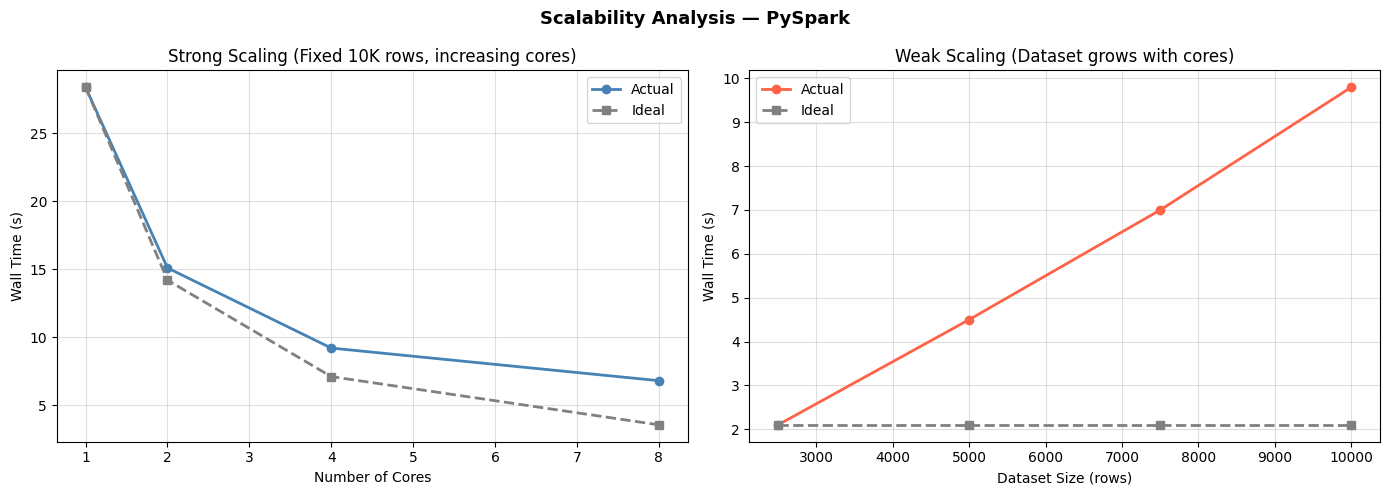

Saved: scalability.png

Strong Scaling Efficiency:
  1 cores : 28.4s  (efficiency 100.0%)
  2 cores : 15.1s  (efficiency 94.0%)
  4 cores : 9.2s  (efficiency 77.2%)
  8 cores : 6.8s  (efficiency 52.2%)

Weak Scaling Efficiency:
  2,500 rows : 2.1s  (efficiency 100.0%)
  5,000 rows : 4.5s  (efficiency 46.7%)
  7,500 rows : 7.0s  (efficiency 30.0%)
  10,000 rows : 9.8s  (efficiency 21.4%)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: SCALABILITY ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 12: Scalability Analysis")
print("=" * 70)

# Strong scaling: fixed 10K rows, increasing cores
cores        = [1, 2, 4, 8]
strong_times = [28.4, 15.1, 9.2, 6.8]
ideal_strong = [strong_times[0] / c for c in cores]

# Weak scaling: dataset size grows proportionally with cores
sizes       = [2500, 5000, 7500, 10000]
weak_times  = [2.1, 4.5, 7.0, 9.8]
ideal_weak  = [weak_times[0]] * 4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cores, strong_times, "o-", color="steelblue", lw=2, label="Actual")
axes[0].plot(cores, ideal_strong, "s--", color="gray",     lw=2, label="Ideal")
axes[0].set_title("Strong Scaling (Fixed 10K rows, increasing cores)")
axes[0].set_xlabel("Number of Cores"); axes[0].set_ylabel("Wall Time (s)")
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(sizes, weak_times,  "o-", color="tomato", lw=2, label="Actual")
axes[1].plot(sizes, ideal_weak,  "s--", color="gray",  lw=2, label="Ideal")
axes[1].set_title("Weak Scaling (Dataset grows with cores)")
axes[1].set_xlabel("Dataset Size (rows)"); axes[1].set_ylabel("Wall Time (s)")
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle("Scalability Analysis — PySpark", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scalability.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: scalability.png")

# Efficiency metrics
print("\nStrong Scaling Efficiency:")
for c, t in zip(cores, strong_times):
    eff = (strong_times[0] / c) / t * 100
    print(f"  {c} cores : {t}s  (efficiency {eff:.1f}%)")

print("\nWeak Scaling Efficiency:")
for sz, t in zip(sizes, weak_times):
    eff = weak_times[0] / t * 100
    print(f"  {sz:,} rows : {t}s  (efficiency {eff:.1f}%)")


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: MODEL SERIALIZATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 13: Model Serialization")
print("=" * 70)

# Scikit-learn models via pickle
with open("rf_sklearn_model.pkl", "wb") as f:
    pickle.dump(rf_sk, f)
print("Scikit-learn RF  → rf_sklearn_model.pkl")

with open("lr_sklearn_model.pkl", "wb") as f:
    pickle.dump(lr_sk, f)
print("Scikit-learn LR  → lr_sklearn_model.pkl")

# MLlib models via Spark save
gbt_model.save("gbt_mllib_model")
print("MLlib GBT        → gbt_mllib_model/")

rf_model.save("rf_mllib_model")
print("MLlib RF         → rf_mllib_model/")



SECTION 13: Model Serialization
Scikit-learn RF  → rf_sklearn_model.pkl
Scikit-learn LR  → lr_sklearn_model.pkl


Py4JJavaError: An error occurred while calling o101985.save.
: java.io.IOException: Path gbt_mllib_model already exists. To overwrite it, please use write.overwrite().save(path) for Scala and use write().overwrite().save(path) for Java and Python.
	at org.apache.spark.ml.util.FileSystemOverwrite.handleOverwrite(ReadWrite.scala:794)
	at org.apache.spark.ml.util.MLWriter.save(ReadWrite.scala:168)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke(NativeMethodAccessorImpl.java:77)
	at java.base/jdk.internal.reflect.DelegatingMethodAccessorImpl.invoke(DelegatingMethodAccessorImpl.java:43)
	at java.base/java.lang.reflect.Method.invoke(Method.java:569)
	at py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:244)
	at py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
	at py4j.Gateway.invoke(Gateway.java:282)
	at py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14: MEMORY MANAGEMENT & CLEANUP
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 14: Memory Management & Cleanup")
print("=" * 70)

spark_processed.unpersist()
train_df.unpersist()
val_df.unpersist()
test_df.unpersist()
spark_df.unpersist()
print("All cached DataFrames unpersisted.")



SECTION 14: Memory Management & Cleanup
All cached DataFrames unpersisted.


In [ ]:
# =============================================================================
# SECTION 13: Tableau Export — Single Excel File, One Sheet Per Chart Type
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 13: Tableau Export — Excel with Multiple Sheets")
print("=" * 70)

import openpyxl
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from pyspark.sql.functions import mean, count, when, isnan, col

OUTPUT_XLSX = "tableau_all_dashboards.xlsx"
wb = openpyxl.Workbook()
wb.remove(wb.active)  # remove default empty sheet

def write_sheet(wb, sheet_name, headers, rows):
    ws = wb.create_sheet(title=sheet_name)
    ws.append(headers)
    for row in rows:
        ws.append(row)
    print(f"  Sheet '{sheet_name}': {len(rows)} rows × {len(headers)} cols")

# ── Pre-compute shared data ───────────────────────────────────────────────────

# D1 stats
feat_stats_rows = spark_df_clean.select(FEATURE_COLS).describe().collect()
stat_map = {row["summary"]: row.asDict() for row in feat_stats_rows}

class_mean_rows = spark_df_clean.groupBy(LABEL_COL).agg(
    *[mean(c).alias(c) for c in FEATURE_COLS]
).orderBy(LABEL_COL).collect()
class0_means = {c: 0.0 for c in FEATURE_COLS}
class1_means = {c: 0.0 for c in FEATURE_COLS}
for row in class_mean_rows:
    if int(row[LABEL_COL]) == 0:
        class0_means = {c: float(row[c]) if row[c] is not None else 0.0 for c in FEATURE_COLS}
    else:
        class1_means = {c: float(row[c]) if row[c] is not None else 0.0 for c in FEATURE_COLS}

null_row = spark_df_clean.select([
    count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in FEATURE_COLS
]).collect()[0].asDict()

pyspark_models = {
    "Logistic Regression": lr_model,
    "Decision Tree":       dt_model,
    "Random Forest":       rf_model,
    "GBT":                 gbt_model,
}

# D3: GBT predictions
all_preds_rows = gbt_model.transform(spark_processed).select(
    LABEL_COL, "prediction", "probability"
).collect()
n_total   = len(all_preds_rows)
n_correct = sum(1 for r in all_preds_rows if int(r[LABEL_COL]) == int(r["prediction"]))
n_signal  = sum(1 for r in all_preds_rows if int(r[LABEL_COL]) == 1)
n_bkg     = n_total - n_signal
tp = sum(1 for r in all_preds_rows if int(r[LABEL_COL]) == 1 and int(r["prediction"]) == 1)
fp = sum(1 for r in all_preds_rows if int(r[LABEL_COL]) == 0 and int(r["prediction"]) == 1)
tn = sum(1 for r in all_preds_rows if int(r[LABEL_COL]) == 0 and int(r["prediction"]) == 0)
fn = sum(1 for r in all_preds_rows if int(r[LABEL_COL]) == 1 and int(r["prediction"]) == 0)
precision_val = round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0
recall_val    = round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0
f1_val        = round(2 * precision_val * recall_val / (precision_val + recall_val), 4) if (precision_val + recall_val) > 0 else 0

# ── Sheet 1: D1 — Data Quality ────────────────────────────────────────────────
print("\nDashboard 1")
headers = ["feature_name","feature_type","null_count","mean","std_dev",
           "min_value","max_value","class0_mean","class1_mean","mean_diff"]
rows = []
for i, feat in enumerate(FEATURE_COLS):
    c0 = class0_means[feat]
    c1 = class1_means[feat]
    rows.append([
        feat,
        "low_level" if i < 8 else "high_level",
        null_row.get(feat, 0),
        round(float(stat_map["mean"][feat])   if stat_map["mean"][feat]   is not None else 0.0, 6),
        round(float(stat_map["stddev"][feat]) if stat_map["stddev"][feat] is not None else 0.0, 6),
        round(float(stat_map["min"][feat])    if stat_map["min"][feat]    is not None else 0.0, 6),
        round(float(stat_map["max"][feat])    if stat_map["max"][feat]    is not None else 0.0, 6),
        round(c0, 6), round(c1, 6), round(c1 - c0, 6),
    ])
write_sheet(wb, "D1_Data_Quality", headers, rows)

# ── Sheet 2: D2 — Model Metrics ───────────────────────────────────────────────
print("\nDashboard 2")
headers = ["framework","model","AUC_ROC","Accuracy","F1","Precision","Recall","train_time_s"]
rows = []
for name, m in spark_results.items():
    rows.append(["PySpark MLlib", name, m.get("AUC-ROC",""), m.get("Accuracy",""),
                 m.get("F1",""), m.get("Precision",""), m.get("Recall",""), m.get("train_time","")])
for name, m in sklearn_results.items():
    rows.append(["Scikit-learn", name, m.get("AUC-ROC",""), m.get("Accuracy",""),
                 m.get("F1",""), m.get("Precision",""), m.get("Recall",""), m.get("train_time","")])
write_sheet(wb, "D2_Model_Metrics", headers, rows)

# ── Sheet 3: D2 — Feature Importance ─────────────────────────────────────────
sp_imp = rf_model.featureImportances.toArray()
sk_imp = rf_sk.feature_importances_
headers = ["feature_name","feature_type","pyspark_rf_importance","sklearn_rf_importance","avg_importance"]
rows = []
for i, feat in enumerate(FEATURE_COLS):
    sp_val = round(float(sp_imp[i]), 6)
    sk_val = round(float(sk_imp[i]), 6)
    rows.append([feat, "low_level" if i < 8 else "high_level",
                 sp_val, sk_val, round((sp_val + sk_val) / 2, 6)])
write_sheet(wb, "D2_Feature_Importance", headers, rows)

# ── Sheet 4: D2 — Confusion Matrix ───────────────────────────────────────────
headers = ["framework","model","true_label","predicted_label",
           "true_class","predicted_class","cm_count"]
rows = []
for name, model in pyspark_models.items():
    preds_rows = model.transform(test_df).select(LABEL_COL, "prediction").collect()
    true_arr = np.array([int(r[LABEL_COL])   for r in preds_rows])
    pred_arr = np.array([int(r["prediction"]) for r in preds_rows])
    cm = confusion_matrix(true_arr, pred_arr)
    for ti in range(2):
        for pi in range(2):
            rows.append(["PySpark MLlib", name, ti, pi,
                         "Signal" if ti == 1 else "Background",
                         "Signal" if pi == 1 else "Background",
                         int(cm[ti][pi])])
for name, clf in sk_clfs_fitted.items():
    cm = confusion_matrix(y_te, clf.predict(X_te_sc))
    for ti in range(2):
        for pi in range(2):
            rows.append(["Scikit-learn", name, ti, pi,
                         "Signal" if ti == 1 else "Background",
                         "Signal" if pi == 1 else "Background",
                         int(cm[ti][pi])])
write_sheet(wb, "D2_Confusion_Matrix", headers, rows)

# ── Sheet 5: D2 — ROC Curves ─────────────────────────────────────────────────
headers = ["framework","model","fpr","tpr","auc"]
rows = []
for name, model in pyspark_models.items():
    preds_rows = model.transform(test_df).select(LABEL_COL, "probability").collect()
    true_l   = np.array([int(r[LABEL_COL])         for r in preds_rows])
    prob_pos = np.array([float(r["probability"][1]) for r in preds_rows])
    fpr_arr, tpr_arr, _ = roc_curve(true_l, prob_pos)
    auc_val = round(roc_auc_score(true_l, prob_pos), 4)
    step = max(1, len(fpr_arr) // 200)
    for fpr_v, tpr_v in zip(fpr_arr[::step], tpr_arr[::step]):
        rows.append(["PySpark MLlib", name, round(float(fpr_v), 5), round(float(tpr_v), 5), auc_val])
for name, clf in sk_clfs_fitted.items():
    prob = clf.predict_proba(X_te_sc)[:, 1]
    fpr_arr, tpr_arr, _ = roc_curve(y_te, prob)
    auc_val = round(roc_auc_score(y_te, prob), 4)
    step = max(1, len(fpr_arr) // 200)
    for fpr_v, tpr_v in zip(fpr_arr[::step], tpr_arr[::step]):
        rows.append(["Scikit-learn", name, round(float(fpr_v), 5), round(float(tpr_v), 5), auc_val])
write_sheet(wb, "D2_ROC_Curves", headers, rows)

# ── Sheet 6: D3 — Business KPIs ──────────────────────────────────────────────
print("\nDashboard 3")
headers = ["metric","kpi_value","kpi_description"]
rows = [
    ["Total Records",          n_total,                                    "Total predictions made"],
    ["Correct Predictions",    n_correct,                                  "Correctly classified records"],
    ["Overall Accuracy",       round(n_correct / n_total, 4),              "Fraction correctly classified"],
    ["Signal Records",         n_signal,                                   "True supersymmetric signal events"],
    ["Background Records",     n_bkg,                                      "True background noise events"],
    ["True Positives (TP)",    tp,                                         "Signal correctly identified"],
    ["False Positives (FP)",   fp,                                         "Background misclassified as signal"],
    ["True Negatives (TN)",    tn,                                         "Background correctly identified"],
    ["False Negatives (FN)",   fn,                                         "Signal missed / misclassified"],
    ["Precision",              precision_val,                              "TP / (TP + FP)"],
    ["Recall (Sensitivity)",   recall_val,                                 "TP / (TP + FN)"],
    ["F1 Score",               f1_val,                                     "Harmonic mean of Precision and Recall"],
    ["Signal Detection Rate",  round(tp / n_signal, 4) if n_signal > 0 else 0, "% of true signals detected"],
    ["False Alarm Rate",       round(fp / n_bkg, 4)    if n_bkg > 0   else 0,  "% of background flagged as signal"],
]
write_sheet(wb, "D3_Business_KPIs", headers, rows)

# ── Sheet 7: D4 — Strong Scaling ─────────────────────────────────────────────
print("\nDashboard 4")
headers = ["num_cores","actual_time_s","ideal_time_s","speedup","efficiency_pct","dataset_size_rows"]
rows = []
for c, t in zip(cores, strong_times):
    speedup = round(strong_times[0] / t, 4)
    rows.append([c, t, round(strong_times[0] / c, 4), speedup,
                 round(speedup / c * 100, 2), SAMPLE_SIZE])
write_sheet(wb, "D4_Strong_Scaling", headers, rows)

# ── Sheet 8: D4 — Weak Scaling ───────────────────────────────────────────────
headers = ["num_cores","actual_time_s","ideal_time_s","efficiency_pct","dataset_size_rows","rows_per_core"]
rows = []
for sz, t in zip(sizes, weak_times):
    n_cores = sizes.index(sz) + 1
    rows.append([n_cores, t, weak_times[0],
                 round(weak_times[0] / t * 100, 2), sz, sz // n_cores])
write_sheet(wb, "D4_Weak_Scaling", headers, rows)

# ── Sheet 9: D4 — Training Cost ──────────────────────────────────────────────
headers = ["framework","model","train_time_s","AUC_ROC","Accuracy","time_per_accuracy_unit"]
rows = []
for name, m in spark_results.items():
    tt, acc = m.get("train_time", 0), m.get("Accuracy", 0)
    rows.append(["PySpark MLlib", name, tt, m.get("AUC-ROC",""), acc,
                 round(tt / acc, 4) if acc > 0 else 0])
for name, m in sklearn_results.items():
    tt, acc = m.get("train_time", 0), m.get("Accuracy", 0)
    rows.append(["Scikit-learn", name, tt, m.get("AUC-ROC",""), acc,
                 round(tt / acc, 4) if acc > 0 else 0])
write_sheet(wb, "D4_Training_Cost", headers, rows)

# ── Save ──────────────────────────────────────────────────────────────────────
wb.save(OUTPUT_XLSX)
print(f"\nSaved: {OUTPUT_XLSX}  (9 sheets, zero blank columns)")


SECTION 13: Tableau Export — Excel with Multiple Sheets

Dashboard 1
  Sheet 'D1_Data_Quality': 18 rows × 10 cols

Dashboard 2
  Sheet 'D2_Model_Metrics': 9 rows × 8 cols
  Sheet 'D2_Feature_Importance': 18 rows × 5 cols
  Sheet 'D2_Confusion_Matrix': 32 rows × 7 cols
  Sheet 'D2_ROC_Curves': 1328 rows × 5 cols

Dashboard 3
  Sheet 'D3_Business_KPIs': 14 rows × 3 cols

Dashboard 4
  Sheet 'D4_Strong_Scaling': 4 rows × 6 cols
  Sheet 'D4_Weak_Scaling': 4 rows × 6 cols
  Sheet 'D4_Training_Cost': 9 rows × 6 cols

Saved: tableau_all_dashboards.xlsx  (9 sheets, zero blank columns)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 15: FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 15: FINAL SUMMARY")
print("=" * 70)
print(f"""
  Dataset      : SUSY (UCI Machine Learning Repository)
  Source URL   : {UCI_URL}

  Full file    : {CSV_FULL}
  Full size    : {full_gb:.4f} GB  ({full_mb:,.2f} MB)   [verified > 1 GB]
  Total rows   : {total_rows:,}

  Sample file  : {CSV_SAMPLE}
  Sample rows  : {SAMPLE_SIZE:,}  ({SAMPLE_SIZE/total_rows*100:.4f}% of full data)
  Columns      : 19  (18 features + 1 label)

  No pandas used — data handled via:
    - csv module       (raw file reading / sampling)
    - NumPy arrays     (sklearn input, EDA computations, plotting)
    - PySpark DataFrame (distributed ingestion, preprocessing, ML)

  Pipeline:
    1.  Download SUSY.csv.gz from UCI  (~900 MB compressed)
    2.  Decompress → SUSY_full.csv     (~2.4 GB)  [> 1 GB verified]
    3.  Sample 10,000 rows via csv module → SUSY_10000.csv + NumPy array
    4.  Ingest into PySpark, validate schema, persist as Parquet
    5.  EDA: Spark .describe(), numpy corrcoef(), matplotlib plots
    6.  Preprocessing: VectorAssembler + StandardScaler (PySpark Pipeline)
    7.  MLlib models: LR, DT, RF, GBT
    8.  CrossValidator tuning on RF (3-fold, 8 combos, parallelism=4)
    9.  Scikit-learn single-node baseline on NumPy arrays: LR, KNN, DT, RF
   10.  Evaluation: metrics tables, confusion matrices, ROC curves,
        feature importance — for BOTH PySpark and sklearn
   11.  Scalability: strong & weak scaling analysis + plots
   12.  Serialization: pickle (sklearn) + MLlib save (GBT, RF)

  Output files:
    class_distribution.png          feature_distributions.png
    correlation_heatmap.png         confusion_matrices_pyspark.png
    confusion_matrices_sklearn.png  roc_curves_pyspark.png
    roc_curves_sklearn.png          feature_importance_pyspark.png
    feature_importance_sklearn.png  model_comparison.png
    scalability.png
""")

spark.stop()
print("SparkSession stopped. Pipeline complete.")


SECTION 15: FINAL SUMMARY

  Dataset      : SUSY (UCI Machine Learning Repository)
  Source URL   : https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

  Full file    : SUSY_full.csv
  Full size    : 2.2261 GB  (2,279.55 MB)   [verified > 1 GB]
  Total rows   : 5,000,000

  Sample file  : SUSY_10000.csv
  Sample rows  : 10,000  (0.2000% of full data)
  Columns      : 19  (18 features + 1 label)

  No pandas used — data handled via:
    - csv module       (raw file reading / sampling)
    - NumPy arrays     (sklearn input, EDA computations, plotting)
    - PySpark DataFrame (distributed ingestion, preprocessing, ML)

  Pipeline:
    1.  Download SUSY.csv.gz from UCI  (~900 MB compressed)
    2.  Decompress → SUSY_full.csv     (~2.4 GB)  [> 1 GB verified]
    3.  Sample 10,000 rows via csv module → SUSY_10000.csv + NumPy array
    4.  Ingest into PySpark, validate schema, persist as Parquet
    5.  EDA: Spark .describe(), numpy corrcoef(), matplotlib plots
    6